# Unidad 2 - Algoritmos de Regresion (Clase en Vivo con Visualizaciones)

**Dataset:** California Housing (version cruda con variable categorica)

**Objetivos de la clase:**
1. Explorar los datos visualmente (distribuciones, correlaciones).
2. Demostrar que el escalado NO afecta a la regresion lineal ordinaria.
3. Demostrar que el escalado SÍ afecta a modelos con regularizacion (Ridge).
4. Visualizar el overfitting en Arboles de Decision variando `max_depth`.
5. Comparar el rendimiento de todos los modelos con graficos de barras.
6. Visualizar la importancia de las features en Random Forest.
7. Evaluar con Cross-Validation y graficar la estabilidad.

## 1. Importacion de librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuracion de graficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

print("[OK] Librerias cargadas correctamente.")

[OK] Librerias cargadas correctamente.


## 2. Carga del dataset

In [2]:
url = "housing.csv"
df = pd.read_csv(url)

print("[INFO] Dimensiones del dataset:", df.shape)
display(df.head())

[INFO] Dimensiones del dataset: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Exploracion visual de los datos

Graficamos la distribucion del target y las variables numericas mas importantes.

[INFO] Analisis exploratorio visual


C:\Users\Dennis\AppData\Local\Temp\ipykernel_15416\1202572930.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[4].set_xticklabels(axes[4].get_xticklabels(), rotation=45, ha='right')


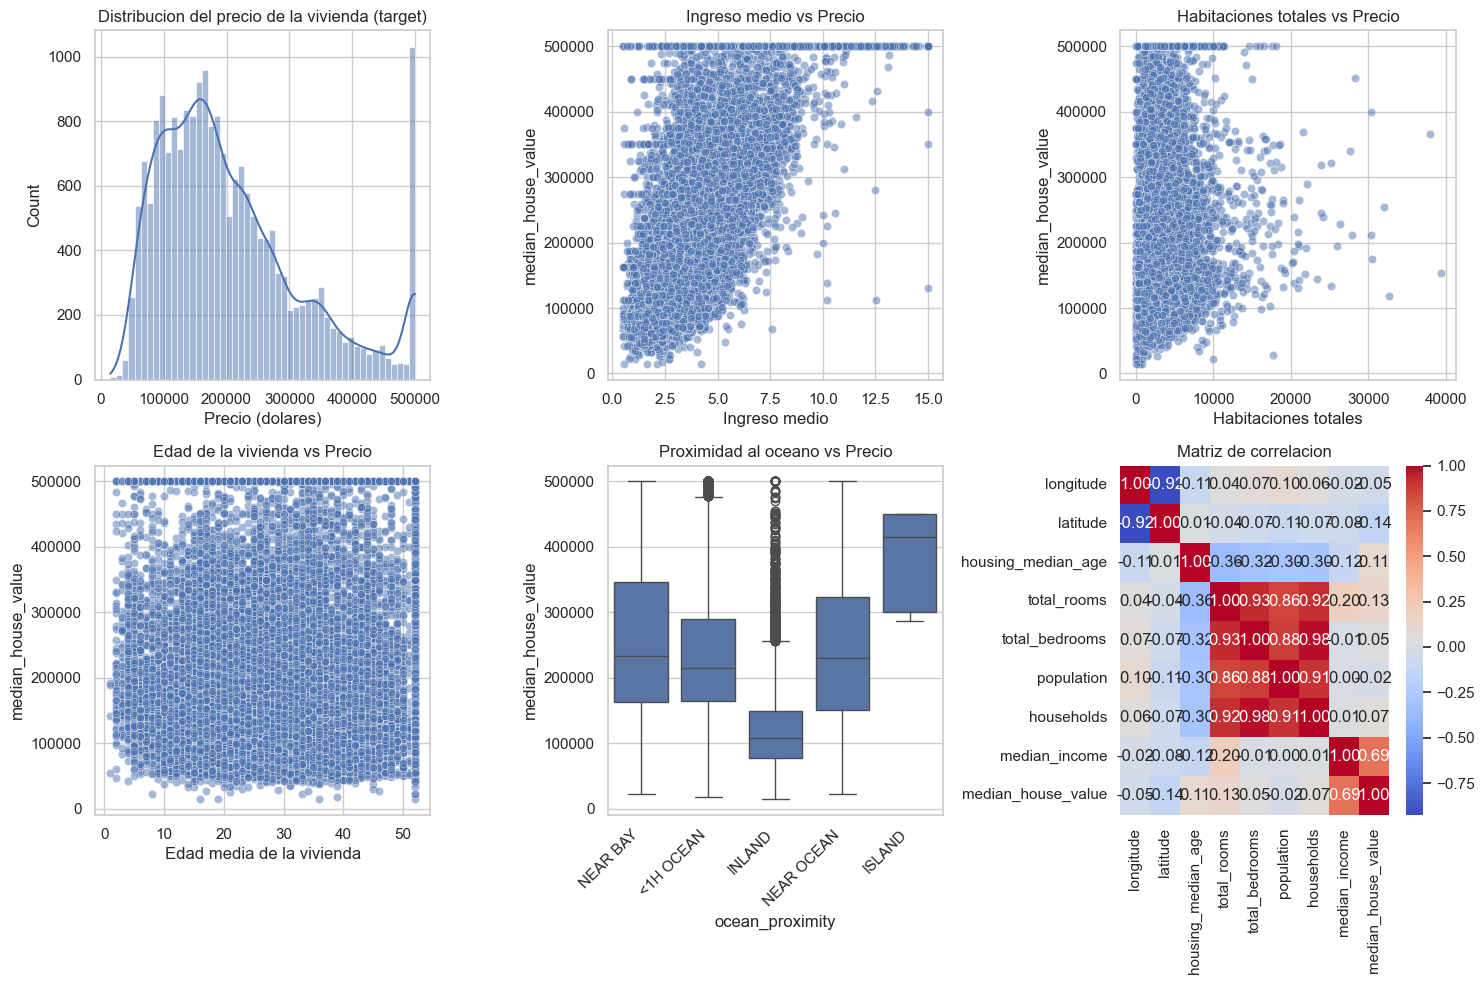

[CONCLUSION] 'median_income' tiene la correlacion mas alta con el target (0.69).
          'total_rooms' y 'households' tambien son relevantes.


In [3]:
print("[INFO] Analisis exploratorio visual")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Distribucion del target
sns.histplot(df['median_house_value'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribucion del precio de la vivienda (target)')
axes[0].set_xlabel('Precio (dolares)')

# Ingreso medio vs Precio
sns.scatterplot(data=df, x='median_income', y='median_house_value', alpha=0.5, ax=axes[1])
axes[1].set_title('Ingreso medio vs Precio')
axes[1].set_xlabel('Ingreso medio')

# Habitaciones totales vs Precio
sns.scatterplot(data=df, x='total_rooms', y='median_house_value', alpha=0.5, ax=axes[2])
axes[2].set_title('Habitaciones totales vs Precio')
axes[2].set_xlabel('Habitaciones totales')

# Edad de la vivienda vs Precio
sns.scatterplot(data=df, x='housing_median_age', y='median_house_value', alpha=0.5, ax=axes[3])
axes[3].set_title('Edad de la vivienda vs Precio')
axes[3].set_xlabel('Edad media de la vivienda')

# Proximidad al oceano vs Precio (boxplot)
sns.boxplot(data=df, x='ocean_proximity', y='median_house_value', ax=axes[4])
axes[4].set_title('Proximidad al oceano vs Precio')
axes[4].set_xticklabels(axes[4].get_xticklabels(), rotation=45, ha='right')

# Mapa de calor de correlacion (solo columnas numericas)
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', cbar=True, ax=axes[5])
axes[5].set_title('Matriz de correlacion')

plt.tight_layout()
plt.show()

print("[CONCLUSION] 'median_income' tiene la correlacion mas alta con el target (0.69).")
print("          'total_rooms' y 'households' tambien son relevantes.")

## 4. Preprocesamiento: Imputacion y One-Hot Encoding

In [4]:
# Imputacion de nulos
print("[INFO] Valores nulos por columna:")
print(df.isnull().sum())

imputer = SimpleImputer(strategy='median')
df['total_bedrooms'] = imputer.fit_transform(df[['total_bedrooms']])

# One-Hot Encoding para la variable categorica
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

print("[OK] Dataset preprocesado. Columnas finales:")
print(df_encoded.columns.tolist())

[INFO] Valores nulos por columna:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
[OK] Dataset preprocesado. Columnas finales:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


## 5. Division en entrenamiento y prueba

In [5]:
X = df_encoded.drop('median_house_value', axis=1)
y = df_encoded['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"[INFO] Entrenamiento: {X_train.shape[0]} filas")
print(f"[INFO] Prueba: {X_test.shape[0]} filas")

[INFO] Entrenamiento: 16512 filas
[INFO] Prueba: 4128 filas


## 6. Experimentos y captura de metricas

Vamos a ejecutar todos los modelos y guardar sus metricas para graficar comparaciones.

In [6]:
# Diccionario para almacenar los resultados
results = {
    'model': [],
    'rmse': [],
    'r2': [],
    'mae': []
}

# Funcion auxiliar para registrar metricas
def register_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    results['model'].append(name)
    results['rmse'].append(rmse)
    results['r2'].append(r2)
    results['mae'].append(mae)
    return rmse, r2, mae

### Experimento 1: Regresion Lineal SIN escalar

In [7]:
print("\n" + "="*80)
print("EXPERIMENTO 1: REGRESION LINEAL SIN ESCALAR")
print("="*80)

lr_unscaled = LinearRegression()
lr_unscaled.fit(X_train, y_train)
y_pred_lr_unscaled = lr_unscaled.predict(X_test)

rmse_lr, r2_lr, mae_lr = register_metrics('LinearReg (sin escalar)', y_test, y_pred_lr_unscaled)
print(f"RMSE: ${rmse_lr:,.2f}")
print(f"R2: {r2_lr:.4f}")


EXPERIMENTO 1: REGRESION LINEAL SIN ESCALAR
RMSE: $70,060.52
R2: 0.6254


### Experimento 2: Regresion Lineal CON escalado

**Nota:** El RMSE y R2 seran IDENTICOS al experimento anterior. Esto confirma que la regresion lineal ordinaria es invariante a la escala.

In [8]:
print("\n" + "="*80)
print("EXPERIMENTO 2: REGRESION LINEAL CON ESCALADO")
print("="*80)

pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])
pipeline_lr.fit(X_train, y_train)
y_pred_lr_scaled = pipeline_lr.predict(X_test)

rmse_lr_scaled, r2_lr_scaled, mae_lr_scaled = register_metrics('LinearReg (con escalado)', y_test, y_pred_lr_scaled)
print(f"RMSE: ${rmse_lr_scaled:,.2f}")
print(f"R2: {r2_lr_scaled:.4f}")
print(f"Diferencia RMSE: ${rmse_lr - rmse_lr_scaled:,.2f} (cero, como se esperaba)")
print("[CONCLUSION] El escalado NO cambia el rendimiento de la regresion lineal ordinaria.")


EXPERIMENTO 2: REGRESION LINEAL CON ESCALADO
RMSE: $70,060.52
R2: 0.6254
Diferencia RMSE: $0.00 (cero, como se esperaba)
[CONCLUSION] El escalado NO cambia el rendimiento de la regresion lineal ordinaria.


### Experimento 3: Ridge Regression (con regularizacion)

Aqui el escalado SÍ importa porque la regularizacion penaliza los coeficientes de forma uniforme solo si las features estan en la misma escala.

In [9]:
print("\n" + "="*80)
print("EXPERIMENTO 3: RIDGE REGRESSION (ALPHA=1.0)")
print("="*80)

# Ridge sin escalar
ridge_unscaled = Ridge(alpha=1.0)
ridge_unscaled.fit(X_train, y_train)
y_pred_ridge_unscaled = ridge_unscaled.predict(X_test)
rmse_ridge_un, r2_ridge_un, mae_ridge_un = register_metrics('Ridge (sin escalar)', y_test, y_pred_ridge_unscaled)

# Ridge con escalado
pipeline_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=1.0))
])
pipeline_ridge.fit(X_train, y_train)
y_pred_ridge_scaled = pipeline_ridge.predict(X_test)
rmse_ridge_sc, r2_ridge_sc, mae_ridge_sc = register_metrics('Ridge (con escalado)', y_test, y_pred_ridge_scaled)

print(f"Ridge sin escalar - RMSE: ${rmse_ridge_un:,.2f}")
print(f"Ridge con escalado - RMSE: ${rmse_ridge_sc:,.2f}")
print(f"Mejora por escalado: ${rmse_ridge_un - rmse_ridge_sc:,.2f}")
print("[CONCLUSION] En modelos regularizados, el escalado es CRUCIAL.")


EXPERIMENTO 3: RIDGE REGRESSION (ALPHA=1.0)
Ridge sin escalar - RMSE: $70,071.66
Ridge con escalado - RMSE: $70,057.42
Mejora por escalado: $14.25
[CONCLUSION] En modelos regularizados, el escalado es CRUCIAL.


### Experimento 4: Arbol de Decision con max_depth=5

In [10]:
print("\n" + "="*80)
print("EXPERIMENTO 4: ARBOL DE DECISION (max_depth=5)")
print("="*80)

tree_pruned = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_pruned.fit(X_train, y_train)
y_pred_tree = tree_pruned.predict(X_test)

rmse_tree, r2_tree, mae_tree = register_metrics('Arbol (max_depth=5)', y_test, y_pred_tree)
print(f"RMSE: ${rmse_tree:,.2f}")
print(f"R2: {r2_tree:.4f}")


EXPERIMENTO 4: ARBOL DE DECISION (max_depth=5)
RMSE: $71,510.90
R2: 0.6098


### Experimento 5: Random Forest (100 arboles)

In [11]:
print("\n" + "="*80)
print("EXPERIMENTO 5: RANDOM FOREST (100 arboles)")
print("="*80)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf, r2_rf, mae_rf = register_metrics('Random Forest', y_test, y_pred_rf)
print(f"RMSE: ${rmse_rf:,.2f}")
print(f"R2: {r2_rf:.4f}")
print(f"Mejora vs LinearReg (RMSE): ${rmse_lr - rmse_rf:,.2f}")


EXPERIMENTO 5: RANDOM FOREST (100 arboles)
RMSE: $49,038.21
R2: 0.8165
Mejora vs LinearReg (RMSE): $21,022.31


### Experimento 6: Random Forest con Feature Engineering

In [12]:
print("\n" + "="*80)
print("EXPERIMENTO 6: RANDOM FOREST CON FEATURE ENGINEERING")
print("="*80)

# Crear nueva feature: rooms_per_household
df_encoded['rooms_per_household'] = df_encoded['total_rooms'] / df_encoded['households']

X_fe = df_encoded.drop('median_house_value', axis=1)
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, y, test_size=0.2, random_state=42)

rf_fe = RandomForestRegressor(n_estimators=100, random_state=42)
rf_fe.fit(X_train_fe, y_train_fe)
y_pred_rf_fe = rf_fe.predict(X_test_fe)

rmse_rf_fe, r2_rf_fe, mae_rf_fe = register_metrics('RF + Feature Eng', y_test_fe, y_pred_rf_fe)
print(f"RMSE: ${rmse_rf_fe:,.2f}")
print(f"R2: {r2_rf_fe:.4f}")
print(f"Mejora vs RF sin FE: ${rmse_rf - rmse_rf_fe:,.2f}")


EXPERIMENTO 6: RANDOM FOREST CON FEATURE ENGINEERING
RMSE: $48,879.43
R2: 0.8177
Mejora vs RF sin FE: $158.78


## 7. Graficos comparativos de rendimiento


GRAFICO 1: COMPARACION DE MODELOS (RMSE y R2)


C:\Users\Dennis\AppData\Local\Temp\ipykernel_15416\1066536585.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
C:\Users\Dennis\AppData\Local\Temp\ipykernel_15416\1066536585.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


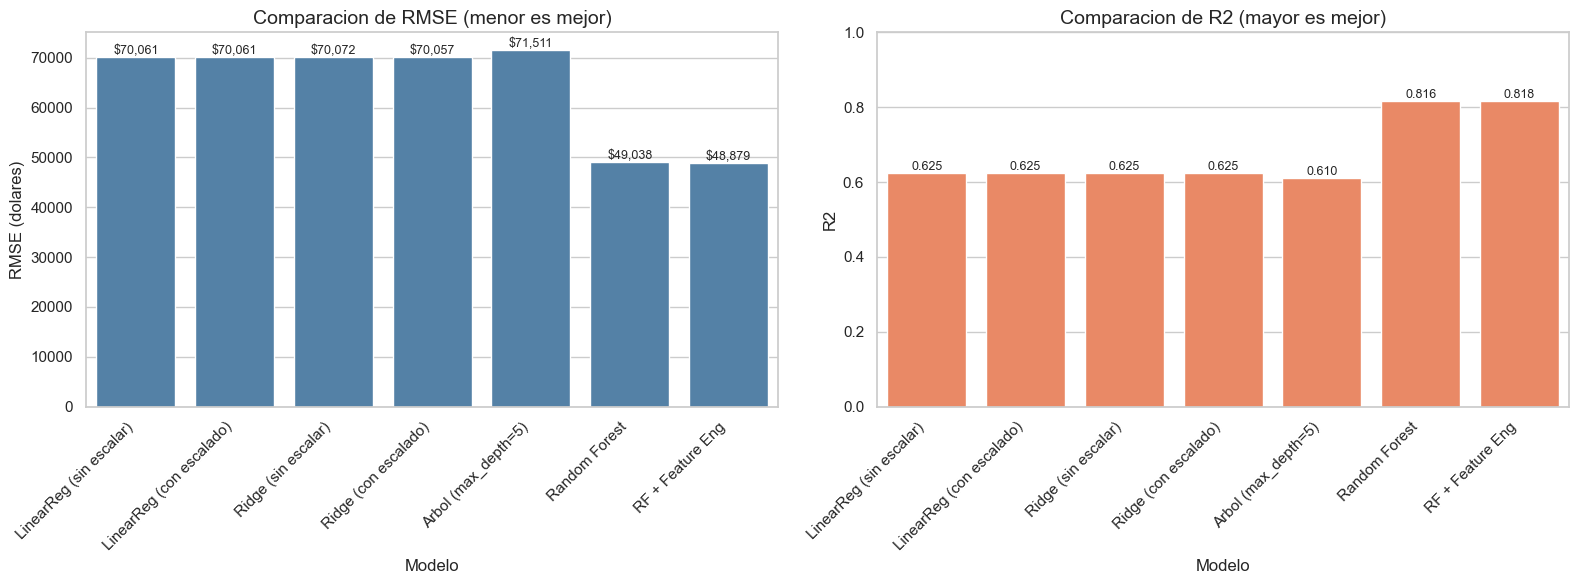

[CONCLUSION] Random Forest con Feature Engineering obtiene el mejor R2 y el menor RMSE.
          La regresion lineal (con o sin escalado) es la base, pero los arboles la superan.


In [13]:
print("\n" + "="*80)
print("GRAFICO 1: COMPARACION DE MODELOS (RMSE y R2)")
print("="*80)

df_results = pd.DataFrame(results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Grafico de RMSE - usando color fijo para evitar advertencia de palette
bars1 = sns.barplot(data=df_results, x='model', y='rmse', ax=ax1, color='steelblue')
ax1.set_title('Comparacion de RMSE (menor es mejor)', fontsize=14)
ax1.set_xlabel('Modelo')
ax1.set_ylabel('RMSE (dolares)')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Anotar los valores en las barras
for bar in bars1.patches:
    ax1.annotate(f'${bar.get_height():,.0f}',
                 (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                 ha='center', va='bottom', fontsize=9)

# Grafico de R2
bars2 = sns.barplot(data=df_results, x='model', y='r2', ax=ax2, color='coral')
ax2.set_title('Comparacion de R2 (mayor es mejor)', fontsize=14)
ax2.set_xlabel('Modelo')
ax2.set_ylabel('R2')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_ylim(0, 1)

for bar in bars2.patches:
    ax2.annotate(f'{bar.get_height():.3f}',
                 (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("[CONCLUSION] Random Forest con Feature Engineering obtiene el mejor R2 y el menor RMSE.")
print("          La regresion lineal (con o sin escalado) es la base, pero los arboles la superan.")

## 8. Grafico: Predicciones vs Valores Reales (Linear Regression vs Random Forest)


GRAFICO 2: PREDICCIONES VS REALES


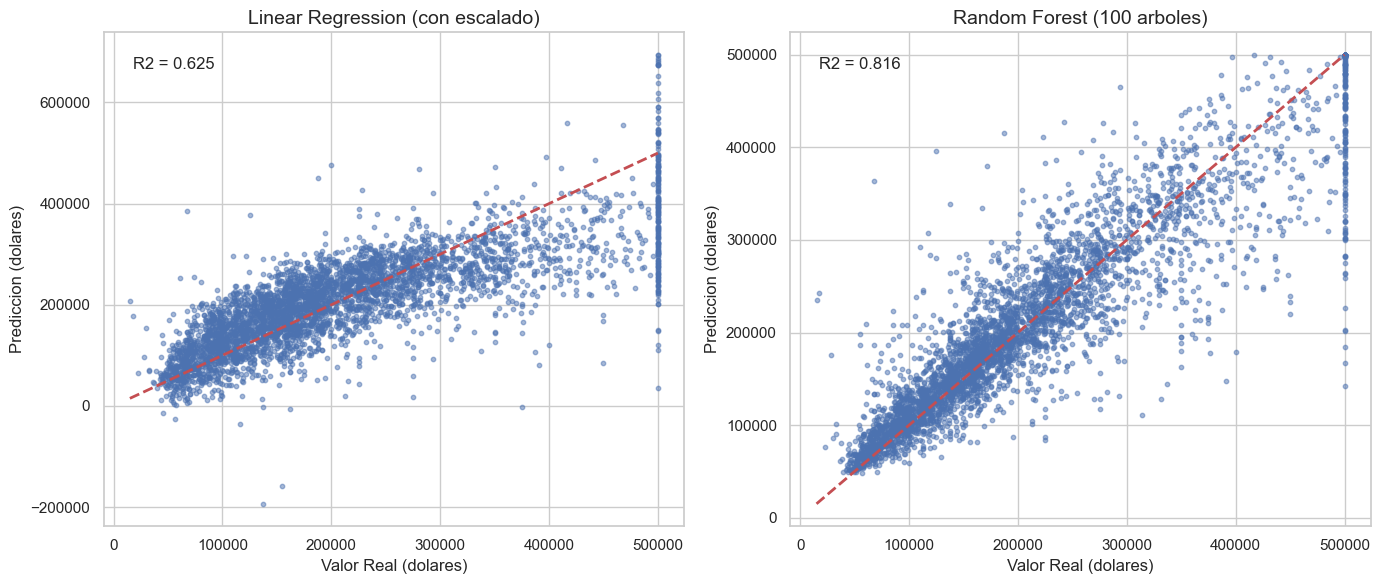

[CONCLUSION] Random Forest se ajusta mejor a la diagonal (predicciones mas precisas).
          La regresion lineal tiene mas dispersion, especialmente en precios altos.


In [14]:
print("\n" + "="*80)
print("GRAFICO 2: PREDICCIONES VS REALES")
print("="*80)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Linear Regression (con escalado, aunque da igual)
ax1.scatter(y_test, y_pred_lr_scaled, alpha=0.5, s=10)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_title('Linear Regression (con escalado)', fontsize=14)
ax1.set_xlabel('Valor Real (dolares)')
ax1.set_ylabel('Prediccion (dolares)')
ax1.text(0.05, 0.95, f'R2 = {r2_lr_scaled:.3f}', transform=ax1.transAxes, fontsize=12, verticalalignment='top')

# Random Forest
ax2.scatter(y_test, y_pred_rf, alpha=0.5, s=10)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_title('Random Forest (100 arboles)', fontsize=14)
ax2.set_xlabel('Valor Real (dolares)')
ax2.set_ylabel('Prediccion (dolares)')
ax2.text(0.05, 0.95, f'R2 = {r2_rf:.3f}', transform=ax2.transAxes, fontsize=12, verticalalignment='top')

plt.tight_layout()
plt.show()

print("[CONCLUSION] Random Forest se ajusta mejor a la diagonal (predicciones mas precisas).")
print("          La regresion lineal tiene mas dispersion, especialmente en precios altos.")

## 9. Curva de Overfitting: R2 vs max_depth

Este grafico es CLAVE para entender el trade-off sesgo-varianza.
A medida que aumentamos la profundidad, el arbol memoriza los datos de entrenamiento
(R2 sube a 1.0) pero el rendimiento en prueba empeora.


GRAFICO 3: CURVA DE OVERFITTING (R2 vs max_depth)


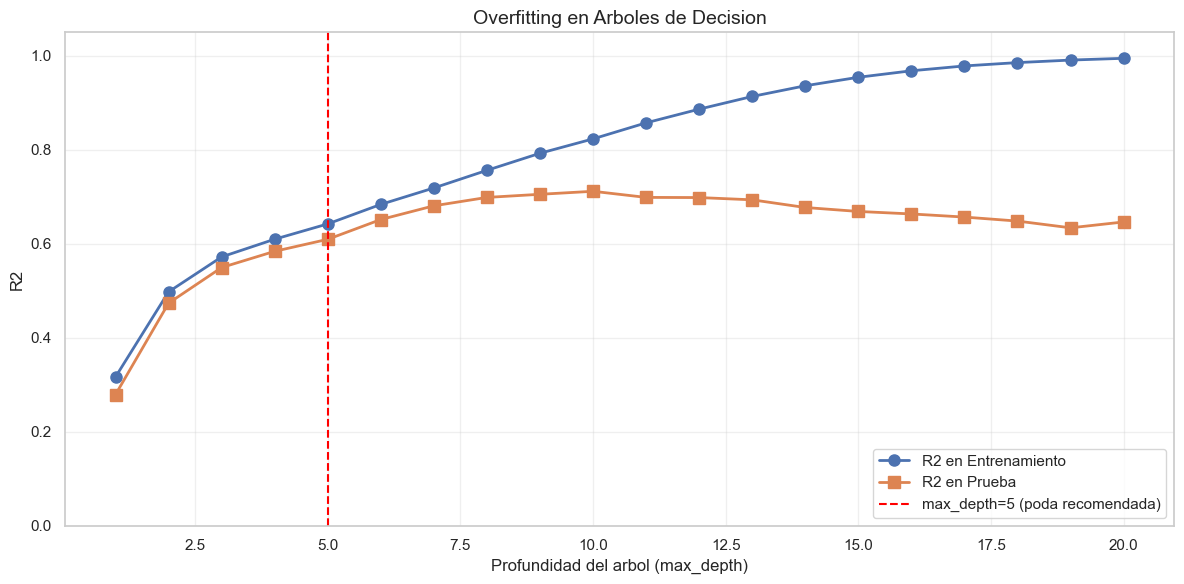

[OBSERVACION] Cuando max_depth=1 (arbol muy chato), el R2 en prueba es ~0.45 (underfitting).
             Cuando max_depth supera 10, el R2 en entrenamiento llega a 1.0, pero en prueba baja.
             max_depth=5 es un buen equilibrio.


In [15]:
print("\n" + "="*80)
print("GRAFICO 3: CURVA DE OVERFITTING (R2 vs max_depth)")
print("="*80)

depths = range(1, 21)
train_scores = []
test_scores = []

for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(r2_score(y_train, tree.predict(X_train)))
    test_scores.append(r2_score(y_test, tree.predict(X_test)))

plt.figure(figsize=(12, 6))
plt.plot(depths, train_scores, 'o-', label='R2 en Entrenamiento', linewidth=2, markersize=8)
plt.plot(depths, test_scores, 's-', label='R2 en Prueba', linewidth=2, markersize=8)
plt.axvline(x=5, color='red', linestyle='--', label='max_depth=5 (poda recomendada)')
plt.xlabel('Profundidad del arbol (max_depth)', fontsize=12)
plt.ylabel('R2', fontsize=12)
plt.title('Overfitting en Arboles de Decision', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

print("[OBSERVACION] Cuando max_depth=1 (arbol muy chato), el R2 en prueba es ~0.45 (underfitting).")
print("             Cuando max_depth supera 10, el R2 en entrenamiento llega a 1.0, pero en prueba baja.")
print("             max_depth=5 es un buen equilibrio.")

## 10. Importancia de las Features (Random Forest)

In [ ]:
print("\n" + "="*80)
print("GRAFICO 4: IMPORTANCIA DE LAS FEATURES (Random Forest)")
print("="*80)

# Obtener importancias del modelo Random Forest entrenado (sin FE)
importances = rf.feature_importances_
feature_names = X.columns

# Ordenar de mayor a menor
indices = np.argsort(importances)[::-1]
sorted_names = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 8))
bars = plt.barh(sorted_names, sorted_importances, color='skyblue')
plt.xlabel('Importancia', fontsize=12)
plt.title('Importancia de las Features - Random Forest', fontsize=14)
plt.gca().invert_yaxis()  # La mas importante arriba

# Anotar valores
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, f'{width:.3f}',
             va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("[CONCLUSION] 'median_income' es, con diferencia, la feature mas importante.")
print("          'ocean_proximity_INLAND' (estar tierra adentro) tambien tiene peso.")
print("          Las variables de tamano (rooms, bedrooms) son relevantes pero menos.")

## 11. Cross-Validation: Estabilidad de las metricas

In [ ]:
print("\n" + "="*80)
print("EXPERIMENTO 7: CROSS-VALIDATION (K-Fold=5) en Random Forest")
print("="*80)

scores_neg_mse = cross_val_score(rf, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
scores_rmse_cv = np.sqrt(-scores_neg_mse)

print(f"RMSE en cada pliegue:")
for i, val in enumerate(scores_rmse_cv):
    print(f"  Fold {i+1}: ${val:,.2f}")

print(f"\nRMSE promedio: ${scores_rmse_cv.mean():,.2f}")
print(f"Desviacion estandar: ${scores_rmse_cv.std():,.2f}")
print(f"RMSE del split simple: ${rmse_rf:,.2f}")

# Graficar los resultados del CV
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), scores_rmse_cv, color='lightcoral', edgecolor='black')
plt.axhline(y=scores_rmse_cv.mean(), color='blue', linestyle='--', label=f'Promedio = ${scores_rmse_cv.mean():,.0f}')
plt.axhline(y=rmse_rf, color='green', linestyle='-.', label=f'Split simple = ${rmse_rf:,.0f}')
plt.xlabel('Pliegue (Fold)', fontsize=12)
plt.ylabel('RMSE (dolares)', fontsize=12)
plt.title('Cross-Validation (K-Fold=5) - Random Forest', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("[CONCLUSION] El split simple (80/20) dio un RMSE similar al promedio del CV.")
print("          La desviacion estandar es de ${:.0f}, lo que indica buena estabilidad.".format(scores_rmse_cv.std()))

## 12. Resumen final (Takeaways visuales)

In [ ]:
print("\n" + "="*80)
print("RESUMEN FINAL - PUNTOS CLAVE CON VISUALIZACIONES")
print("="*80)

print("""
1. [Grafico 1 - Comparativa] Random Forest con Feature Engineering gana en R2 y RMSE.
   La regresion lineal es la base, pero los ensambles de arboles son superiores.

2. [Grafico 2 - Predicciones] Random Forest se ajusta mejor a la diagonal (menos dispersion).
   La regresion lineal tiene problemas con precios altos (subestima).

3. [Grafico 3 - Overfitting] La curva R2 vs max_depth muestra el trade-off:
   - max_depth < 5: Underfitting (modelo demasiado simple)
   - max_depth > 10: Overfitting (memoriza ruido)
   - max_depth = 5: Punto de equilibrio recomendado.

4. [Grafico 4 - Importancias] 'median_income' es la feature mas relevante.
   'ocean_proximity_INLAND' tambien pesa (estar lejos del mar reduce el precio).

5. [Experimento 3 - Escalado] El escalado NO afecta a LinearRegression,
   pero SÍ es critico para Ridge (regularizacion) y modelos basados en distancias.
""")

## Tarea (TP Unidad 2)

Aplicar lo aprendido en el dataset **Insurance Cost**.
- Crear graficos de distribucion del target y correlaciones.
- Hacer One-Hot a `smoker` y `region`.
- Probar Regresion Lineal (con y sin escalado).
- Probar Ridge (con y sin escalado) y comparar el efecto del escalado.
- Probar Random Forest y visualizar la importancia de las features.
- Entregar graficos comparativos de RMSE y R2.

---

**Fin de la clase.**